(From ChatGPT)

Analysis of Demographic Data: Then and Now
- Before (classic research): demographics are mainly for describing the sample, group comparisons, and controls in an interpretable model.
- Now (big data era): demographics become one part of a larger feature set (often mixed with behavior), used for prediction, feature selection, and segmentation.

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.cluster import MiniBatchKMeans

## Create A Synthetic dataset

In [2]:
np.random.seed(7)

# -----------------------
# A) Create a synthetic dataset
# -----------------------
n = 6000
age = np.random.normal(35, 12, n).clip(18, 75).round(0).astype(int)
gender = np.random.choice(["F", "M"], size=n, p=[0.52, 0.48])
education = np.random.choice(["HS", "BA", "MA+"], size=n, p=[0.35, 0.45, 0.20])
region = np.random.choice(["North", "South", "East", "West"], size=n)

# "Big data era" extra variables (behavioral + many noisy features)
sessions_30d = np.random.poisson(lam=8, size=n)
avg_session_min = np.random.gamma(shape=2.2, scale=3.0, size=n)
emails_opened = np.random.poisson(lam=2.5, size=n)
distance_km = np.random.exponential(scale=4.5, size=n)

noise = np.random.normal(size=(n, 40))
noise_cols = [f"noise_{i:02d}" for i in range(noise.shape[1])]

df = pd.DataFrame({
    "age": age,
    "gender": gender,
    "education": education,
    "region": region,
    "sessions_30d": sessions_30d,
    "avg_session_min": avg_session_min,
    "emails_opened": emails_opened,
    "distance_km": distance_km,
})
df[noise_cols] = noise

# Outcome: purchase (depends weakly on demographics, strongly on behavior)
edu_effect = df["education"].map({"HS": -0.25, "BA": 0.0, "MA+": 0.2}).values
gender_effect = (df["gender"] == "F").astype(float).values * 0.05
age_effect = (df["age"].values - 35) * (-0.012)

behav = (
    0.11 * df["sessions_30d"].values
    + 0.05 * np.log1p(df["emails_opened"].values)
    + 0.02 * df["avg_session_min"].values
    - 0.07 * np.sqrt(df["distance_km"].values)
)

hidden = 0.12 * df["noise_03"].values - 0.10 * df["noise_17"].values

logit = -2.2 + edu_effect + gender_effect + age_effect + behav + hidden
p = 1 / (1 + np.exp(-logit))
df["purchase"] = (np.random.rand(n) < p).astype(int)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 49 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              6000 non-null   int64  
 1   gender           6000 non-null   object 
 2   education        6000 non-null   object 
 3   region           6000 non-null   object 
 4   sessions_30d     6000 non-null   int64  
 5   avg_session_min  6000 non-null   float64
 6   emails_opened    6000 non-null   int64  
 7   distance_km      6000 non-null   float64
 8   noise_00         6000 non-null   float64
 9   noise_01         6000 non-null   float64
 10  noise_02         6000 non-null   float64
 11  noise_03         6000 non-null   float64
 12  noise_04         6000 non-null   float64
 13  noise_05         6000 non-null   float64
 14  noise_06         6000 non-null   float64
 15  noise_07         6000 non-null   float64
 16  noise_08         6000 non-null   float64
 17  noise_09      

## Analysis - Method BEFORE: descriptive demographic analysis

Overall purchase rate: 0.2195

Purchase rate by gender:
purchase  no_purchase  purchase
gender                         
F            0.778812  0.221188
M            0.782322  0.217678

Purchase rate by education:
purchase   no_purchase  purchase
education                       
BA            0.769316  0.230684
HS            0.823473  0.176527
MA+           0.730185  0.269815


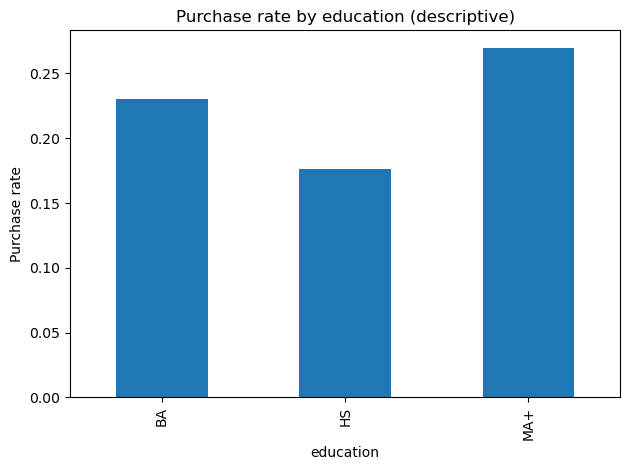

In [3]:

# -----------------------
# B) "BEFORE": descriptive demographic analysis
# -----------------------
print("Overall purchase rate:", df["purchase"].mean())

print("\nPurchase rate by gender:")
print(pd.crosstab(df["gender"], df["purchase"], normalize="index")
        .rename(columns={0:"no_purchase",1:"purchase"}))

print("\nPurchase rate by education:")
print(pd.crosstab(df["education"], df["purchase"], normalize="index")
        .rename(columns={0:"no_purchase",1:"purchase"}))

# Simple plot
purchase_by_edu = df.groupby("education")["purchase"].mean().sort_index()
plt.figure()
purchase_by_edu.plot(kind="bar")
plt.title("Purchase rate by education (descriptive)")
plt.ylabel("Purchase rate")
plt.tight_layout()
plt.show()


## Analysis Method BEFORE: small interpretable model (demographics only)

In [5]:
# -----------------------
# C) "BEFORE": small interpretable model (demographics only)
# -----------------------
X_before = df[["age", "gender", "education", "region"]]
y = df["purchase"]

cat_cols = ["gender", "education", "region"]
num_cols = ["age"]

prep_before = ColumnTransformer([
    ("cat", OneHotEncoder(drop="first"), cat_cols),
    ("num", StandardScaler(), num_cols),
])

model_before = Pipeline([
    ("prep", prep_before),
    ("clf", LogisticRegression(max_iter=2000))
])

X_train, X_test, y_train, y_test = train_test_split(
    X_before, y, test_size=0.25, random_state=7, stratify=y
)

model_before.fit(X_train, y_train)
auc_before = roc_auc_score(y_test, model_before.predict_proba(X_test)[:, 1])
print("\nAUC (demographics only):", auc_before)



AUC (demographics only): 0.5605553666494487


## Analysis Method NOW: many variables + regularization (feature selection)

In [6]:
# -----------------------
# D) "NOW": many variables + regularization (feature selection)
# -----------------------
X_now = df.drop(columns=["purchase"])

cat_cols_now = ["gender", "education", "region"]
num_cols_now = [c for c in X_now.columns if c not in cat_cols_now]

prep_now = ColumnTransformer([
    ("cat", OneHotEncoder(drop="first"), cat_cols_now),
    ("num", StandardScaler(), num_cols_now),
])

# L1 (lasso-like) logistic regression selects a sparse set of predictors
model_now = Pipeline([
    ("prep", prep_now),
    ("clf", LogisticRegression(
        max_iter=4000,
        penalty="l1",
        solver="saga",
        C=0.35,
        n_jobs=-1
    ))
])

X_train, X_test, y_train, y_test = train_test_split(
    X_now, y, test_size=0.25, random_state=7, stratify=y
)

model_now.fit(X_train, y_train)
auc_now = roc_auc_score(y_test, model_now.predict_proba(X_test)[:, 1])
print("\nAUC (demographics + behavior + many features):", auc_now)

# Which features were kept?
ohe = model_now.named_steps["prep"].named_transformers_["cat"]
cat_feature_names = list(ohe.get_feature_names_out(cat_cols_now))
all_feature_names = cat_feature_names + num_cols_now

coefs = model_now.named_steps["clf"].coef_.ravel()
selected = pd.DataFrame({"feature": all_feature_names, "coef": coefs})
selected = selected[selected["coef"].abs() > 1e-6].sort_values("coef", ascending=False)
print("\nTop selected features (positive):")
print(selected.head(12))
print("\nTop selected features (negative):")
print(selected.tail(12))



AUC (demographics + behavior + many features): 0.5974578140938953

Top selected features (positive):
          feature      coef
7    sessions_30d  0.283562
14       noise_03  0.124937
2   education_MA+  0.123304
3    region_North  0.079338
9   emails_opened  0.064806
26       noise_15  0.044945
22       noise_11  0.041760
44       noise_33  0.039839
48       noise_37  0.038519
47       noise_36  0.035114
32       noise_21  0.034742
41       noise_30  0.033587

Top selected features (negative):
         feature      coef
31      noise_20 -0.037874
20      noise_09 -0.038336
19      noise_08 -0.040036
50      noise_39 -0.043525
27      noise_16 -0.049049
6            age -0.065698
10   distance_km -0.072891
11      noise_00 -0.079087
25      noise_14 -0.079938
28      noise_17 -0.104895
33      noise_22 -0.109142
1   education_HS -0.396964


/Users/wudaudau/opt/miniconda3/envs/ds-core/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/wudaudau/opt/miniconda3/envs/ds-core/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/wudaudau/opt/miniconda3/envs/ds-core/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


## Analysis Method NOW: segmentation (clusters) instead of predefined groups


Segment profiles:
               age  sessions_30d  avg_session_min  emails_opened  distance_km  \
segment                                                                         
0        40.882574      9.320107         4.777078       3.438070     2.940446   
1        39.299308      7.318339        13.055276       2.423875     3.646449   
2        34.612472      8.531180         5.982765       2.491091    13.070324   
3        28.236425      6.979337         5.075139       1.789524     3.035315   

         purchase  
segment            
0        0.236461  
1        0.212803  
2        0.201559  
3        0.215762  


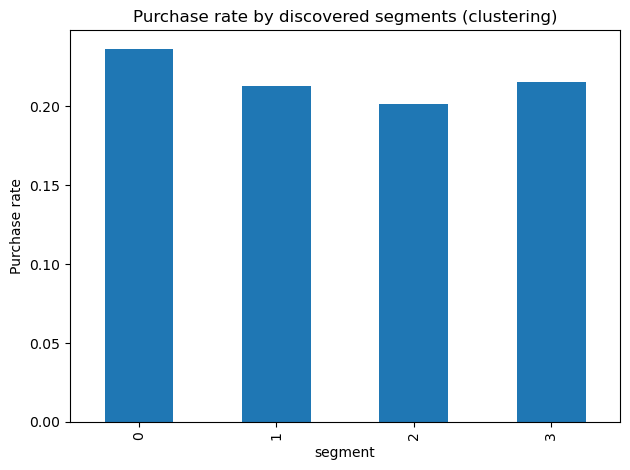

In [7]:


# -----------------------
# E) "NOW": segmentation (clusters) instead of predefined groups
# -----------------------
segment_features = ["age", "sessions_30d", "avg_session_min", "emails_opened", "distance_km"]

seg_pipe = Pipeline([
    ("scale", StandardScaler()),
    ("kmeans", MiniBatchKMeans(n_clusters=4, random_state=7, n_init=5, batch_size=512))
])

df["segment"] = seg_pipe.fit_predict(df[segment_features])
seg_profile = df.groupby("segment")[segment_features + ["purchase"]].mean().sort_index()
print("\nSegment profiles:")
print(seg_profile)

plt.figure()
df.groupby("segment")["purchase"].mean().sort_index().plot(kind="bar")
plt.title("Purchase rate by discovered segments (clustering)")
plt.ylabel("Purchase rate")
plt.tight_layout()
plt.show()